AAI612O: Fundementals Of Deep Learning

Week 8 Project 2 (Final Project)

Title: Deep Learning Model For Seizure Detection

Instructor: Dr. Haidar Harmanani

Student: Sarah Sleiman

ID: 202106919

Description: This is a deep learning model serving as a final project for the course fundementals of deep learning at the Lebanese American University (LAU). The aim is to create a deep learning model accurate for seizure detection from EEGs

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping

Dataset Handling:

In this section, the dataset will be imported and inspected

In [ ]:
df = pd.read_csv("BEED_Data.csv")

In [ ]:
#checking head
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [ ]:
df.shape

(8000, 17)

In [ ]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'y'],
      dtype='object')

In [ ]:
df['y'].value_counts()

,count
y,
0,2000
1,2000
2,2000
3,2000


after checking head and the datset we notice that the dataset is sorted, which will require shuffling.

we can also notice that there is an even split of values for y (2000 for each).

In [ ]:
#shuffling
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
#checking for the shuffle
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,-18,0,-2,-18,-12,-16,-7,-2,5,7,4,-18,-1,4,-6,1,1
1,24,-8,16,-9,17,3,12,-9,7,-2,10,-2,15,-8,21,-13,1
2,-5,10,24,-11,-37,-46,-44,-40,-16,-4,-21,-31,-34,-34,-2,66,0
3,-1,23,17,-3,19,6,2,8,2,-7,23,3,10,3,15,-8,1
4,-2,-6,1,-3,14,-17,-6,-1,1,-9,2,-3,-5,-2,4,-6,2


We can now notice that the dataset is shuffled and moving on to the split wouldnt cause issues.

In [ ]:
#splitting 80/20
X = df.drop(['y'], axis=1)
y = df['y']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
#normalizing
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In this part we will compile a model for testing

In [ ]:
#creating a model
model = Sequential([
    Dense(2048, activation = 'relu', input_shape= (16,)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(1024, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(64, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(4, activation = 'softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compiliing
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 2048)           │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,821,444 (10.76 MB)

 Trainable params: 2,813,636 (10.73 MB)

 Non-trainable params: 7,808 (30.50 KB)

Training the model

In [ ]:
#adding early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
#train
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7295 - loss: 0.6233 - val_accuracy: 0.2438 - val_loss: 2.7795
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8170 - loss: 0.4348 - val_accuracy: 0.3477 - val_loss: 2.6790
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8477 - loss: 0.3760 - val_accuracy: 0.5031 - val_loss: 1.5657
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8584 - loss: 0.3502 - val_accuracy: 0.8813 - val_loss: 0.3098
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8664 - loss: 0.3290 - val_accuracy: 0.9023 - val_loss: 0.2590
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8840 - loss: 0.3029 - val_accuracy: 0.8813 - val_loss: 0.3082
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8799 - loss: 0.3029 - val_accuracy: 0.9078 - val_loss: 0.2533
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8893 - loss: 0.2793 - val_accu

Evaluating model:

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9675 - loss: 0.1058
0.9674999713897705


In [ ]:
#predict
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


analysis:

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Healthy",
        "Generalized Seizure",
        "Focal Seizure",
        "Seizure Event"
    ]
))

                     precision    recall  f1-score   support

            Healthy       1.00      1.00      1.00       411
Generalized Seizure       0.94      0.98      0.96       389
      Focal Seizure       0.97      0.94      0.95       385
      Seizure Event       0.97      0.95      0.96       415

           accuracy                           0.97      1600
          macro avg       0.97      0.97      0.97      1600
       weighted avg       0.97      0.97      0.97      1600



In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[411   0   0   0]
 [  1 380   6   2]
 [  1  11 361  12]
 [  0  12   7 396]]


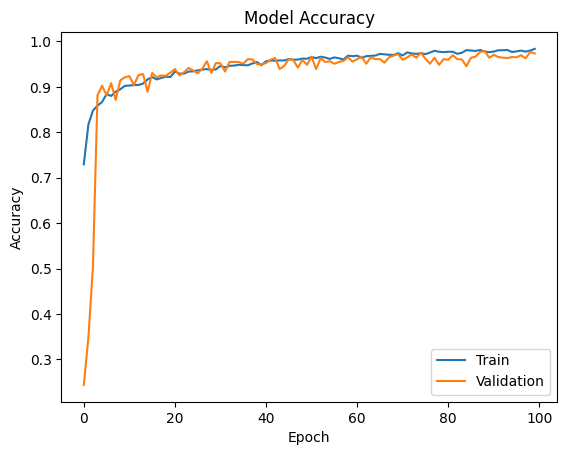

In [ ]:
#accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

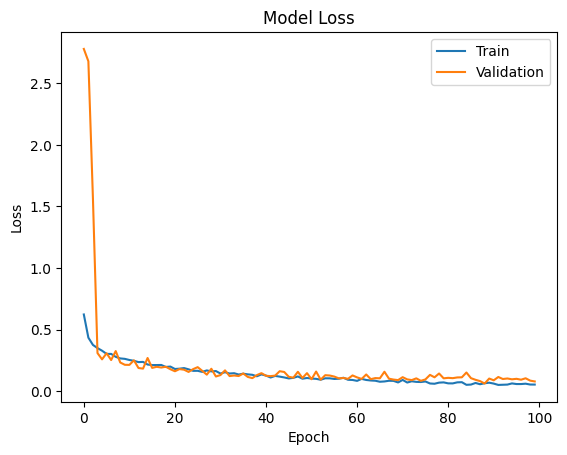

In [ ]:
  #loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()